# North Atlantic Hurricane Activity Since 1970

This notebook analyzes North Atlantic hurricane activity using the NOAA IBTrACS hurricane track dataset. My part of the group project focuses on changes in hurricane activity over time, including annual storm counts, daily datapoint counts, seasonal climatology, and anomalous years.

The main question for this notebook is: how has North Atlantic hurricane activity changed since 1970, and which years stand out as unusually active?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load the NOAA IBTrACS hurricane dataset

I load the NOAA IBTrACS dataset directly from the online CSV file. This keeps the notebook self-contained and reproducible because the data are accessed from within the notebook.

In [2]:
url = "https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv"

df = pd.read_csv(
    url,
    parse_dates=["ISO_TIME"],
    usecols=range(12),
    skiprows=[1],
    na_values=[" ", "NOT_NAMED"],
    keep_default_na=False,
    dtype={"NAME": str}
)

df.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
0,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 03:00:00,NR,10.9000,80.3000,NaN,NaN
1,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 06:00:00,NR,10.8709,79.8265,NaN,NaN
2,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 09:00:00,NR,10.8431,79.3524,NaN,NaN
3,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 12:00:00,NR,10.8188,78.8772,NaN,NaN
4,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 15:00:00,NR,10.8000,78.4000,NaN,NaN


In [3]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))
print("Shape:", df.shape)

df.info()

Number of rows: 716165
Number of columns: 12
Shape: (716165, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 716165 entries, 0 to 716164
Data columns (total 12 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   SID       716165 non-null  object        
 1   SEASON    716165 non-null  int64         
 2   NUMBER    716165 non-null  int64         
 3   BASIN     716165 non-null  object        
 4   SUBBASIN  716165 non-null  object        
 5   NAME      390393 non-null  object        
 6   ISO_TIME  716165 non-null  datetime64[ns]
 7   NATURE    716165 non-null  object        
 8   LAT       716165 non-null  float64       
 9   LON       716165 non-null  float64       
 10  WMO_WIND  157570 non-null  float64       
 11  WMO_PRES  160275 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(5)
memory usage: 65.6+ MB


## 2. Prepare North Atlantic hurricane activity data since 1970

I rename the wind and pressure columns to shorter names. Then I filter the dataset to North Atlantic storms since 1970 and set `ISO_TIME` as the time index for time series analysis.

In [4]:
# Rename columns for easier analysis

df = df.rename(
    columns={
        "WMO_WIND": "WIND",
        "WMO_PRES": "PRES"
    }
)

df.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
0,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 03:00:00,NR,10.9000,80.3000,NaN,NaN
1,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 06:00:00,NR,10.8709,79.8265,NaN,NaN
2,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 09:00:00,NR,10.8431,79.3524,NaN,NaN
3,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 12:00:00,NR,10.8188,78.8772,NaN,NaN
4,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 15:00:00,NR,10.8000,78.4000,NaN,NaN


In [5]:
# Filter to North Atlantic storms since 1970 and set time as the index

df_na = df[
    (df["BASIN"] == "NA") &
    (df["SEASON"] >= 1970)
].copy()

df_na = df_na.set_index("ISO_TIME").sort_index()

print("Number of North Atlantic datapoints since 1970:", len(df_na))
print("Number of unique North Atlantic storms since 1970:", df_na["SID"].nunique())

df_na.head()

Number of North Atlantic datapoints since 1970: 48154
Number of unique North Atlantic storms since 1970: 914


,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,WIND,PRES
ISO_TIME,,,,,,,,,,,
1970-05-17 18:00:00,1970138N12281,1970,43,NA,CS,ALMA,TS,11.5000,-79.0000,25.0,NaN
1970-05-17 21:00:00,1970138N12281,1970,43,NA,CS,ALMA,TS,11.6475,-79.1400,NaN,NaN
1970-05-18 00:00:00,1970138N12281,1970,43,NA,CS,ALMA,TS,11.8000,-79.3000,25.0,NaN
1970-05-18 03:00:00,1970138N12281,1970,43,NA,CS,ALMA,TS,11.9575,-79.4925,NaN,NaN
1970-05-18 06:00:00,1970138N12281,1970,43,NA,CS,ALMA,TS,12.1000,-79.7000,25.0,NaN


In [6]:
df_na.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48154 entries, 1970-05-17 18:00:00 to 2023-11-18 00:00:00
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SID       48154 non-null  object 
 1   SEASON    48154 non-null  int64  
 2   NUMBER    48154 non-null  int64  
 3   BASIN     48154 non-null  object 
 4   SUBBASIN  48154 non-null  object 
 5   NAME      41243 non-null  object 
 6   NATURE    48154 non-null  object 
 7   LAT       48154 non-null  float64
 8   LON       48154 non-null  float64
 9   WIND      23998 non-null  float64
 10  PRES      20304 non-null  float64
dtypes: float64(4), int64(2), object(5)
memory usage: 4.4+ MB


## 3. Annual number of North Atlantic storms since 1970

I count the number of unique North Atlantic storms in each season. This figure shows how annual storm activity has changed over time.

In [7]:
# Count unique storms by season

annual_storm_counts = df_na.groupby("SEASON")["SID"].nunique()

annual_storm_counts.head()

SEASON
1970    23
1971    22
1972    19
1973    17
1974    20
Name: SID, dtype: int64

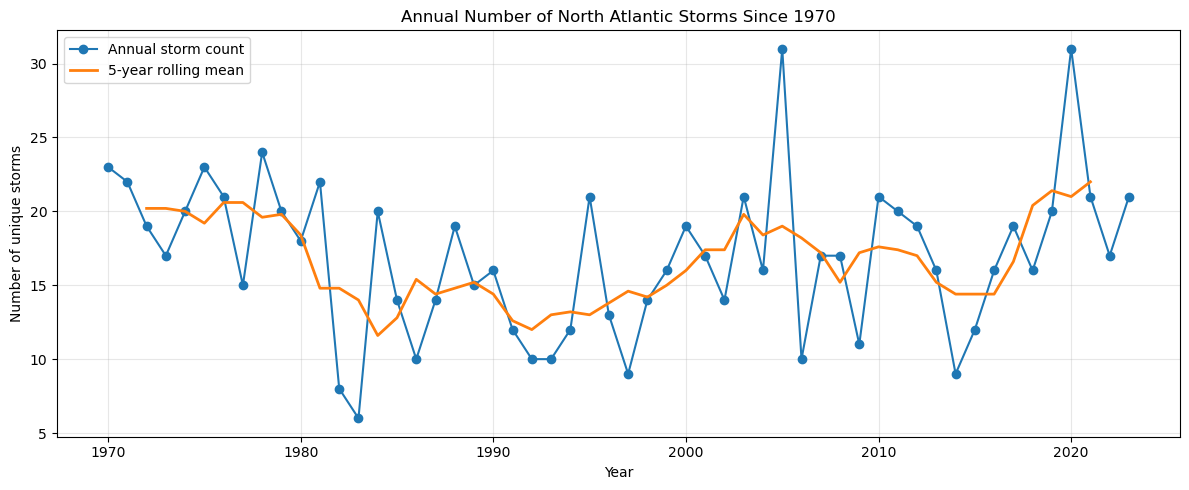

In [8]:
# Plot annual storm counts

fig, ax = plt.subplots(figsize=(12, 5))

annual_storm_counts.plot(
    ax=ax,
    marker="o",
    label="Annual storm count"
)

annual_storm_counts.rolling(5, center=True).mean().plot(
    ax=ax,
    linewidth=2,
    label="5-year rolling mean"
)

ax.set_title("Annual Number of North Atlantic Storms Since 1970")
ax.set_xlabel("Year")
ax.set_ylabel("Number of unique storms")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

The annual number of North Atlantic storms varies substantially from year to year. The 5-year rolling mean helps show the longer-term pattern by smoothing out short-term variability.

## 4. Daily datapoint counts for North Atlantic storms since 1970

I count the number of storm observation datapoints per day. This helps show the timing and intensity of storm activity within each season, because active storm periods have more daily observations.

In [9]:
# Count datapoints per day

daily_counts = df_na.resample("D").size()

daily_counts.head()

ISO_TIME
1970-05-17    2
1970-05-18    8
1970-05-19    8
1970-05-20    8
1970-05-21    8
Freq: D, dtype: int64

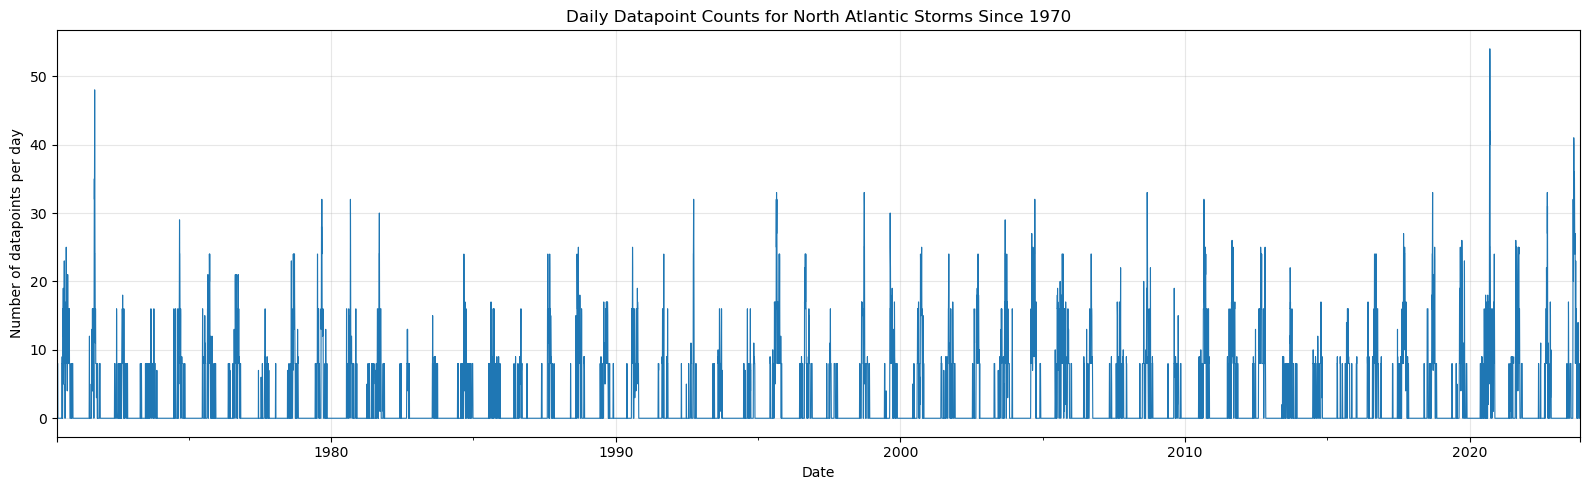

In [10]:
# Plot daily datapoint counts

fig, ax = plt.subplots(figsize=(16, 5))

daily_counts.plot(
    ax=ax,
    linewidth=0.8
)

ax.set_title("Daily Datapoint Counts for North Atlantic Storms Since 1970")
ax.set_xlabel("Date")
ax.set_ylabel("Number of datapoints per day")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The daily datapoint count series is highly seasonal and spiky. Many days have no North Atlantic storm observations, while active storm periods show sharp increases in the number of daily datapoints.

## 5. Seasonal climatology of North Atlantic storm activity

I calculate the average number of North Atlantic storm datapoints for each day of the year. This shows the seasonal cycle of storm activity and identifies when storm activity is usually highest.

In [11]:
# Calculate daily count climatology by day of year

daily_count_df = daily_counts.to_frame(name="count")
daily_count_df["dayofyear"] = daily_count_df.index.dayofyear

daily_count_climatology = daily_count_df.groupby("dayofyear")["count"].agg(["mean", "std"])

daily_count_climatology.head()

,mean,std
dayofyear,,
1,0.150943,1.098885
2,0.150943,1.098885
3,0.150943,1.098885
4,0.150943,1.098885
5,0.150943,1.098885


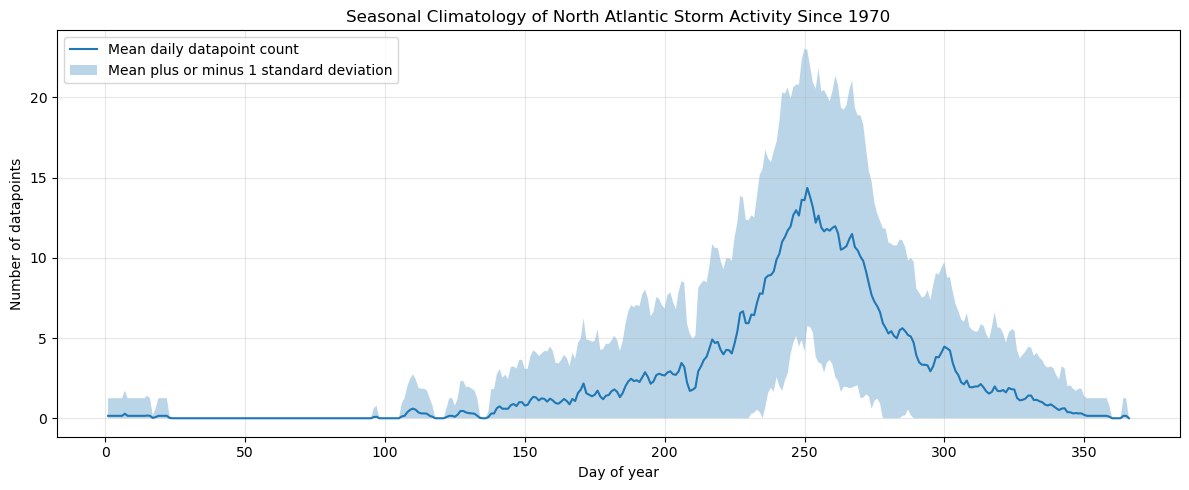

In [12]:
# Plot seasonal climatology

lower = np.maximum(
    daily_count_climatology["mean"] - daily_count_climatology["std"],
    0
)

upper = daily_count_climatology["mean"] + daily_count_climatology["std"]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    daily_count_climatology.index,
    daily_count_climatology["mean"],
    label="Mean daily datapoint count"
)

ax.fill_between(
    daily_count_climatology.index,
    lower,
    upper,
    alpha=0.3,
    label="Mean plus or minus 1 standard deviation"
)

ax.set_title("Seasonal Climatology of North Atlantic Storm Activity Since 1970")
ax.set_xlabel("Day of year")
ax.set_ylabel("Number of datapoints")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

The seasonal climatology shows a clear hurricane season pattern. North Atlantic storm activity is low during the early part of the year, rises during the summer, reaches its highest level around late summer and early fall, and then declines toward the end of the year.

## 6. Annual anomalies in North Atlantic storm activity

I remove the day-of-year climatology from the daily datapoint count time series. This creates an anomaly series that shows whether each day has more or fewer storm datapoints than the typical value for that day of the year. I then sum these anomalies by year to identify years with unusually high or low storm activity.

In [13]:
# Calculate daily count anomalies from day-of-year climatology

def remove_climatology(x):
    return x - x.mean()

daily_count_anomaly = daily_counts.groupby(
    daily_counts.index.dayofyear
).transform(remove_climatology)

daily_count_anomaly.head()

ISO_TIME
1970-05-17    1.925926
1970-05-18    7.703704
1970-05-19    7.703704
1970-05-20    7.370370
1970-05-21    7.259259
Freq: D, dtype: float64

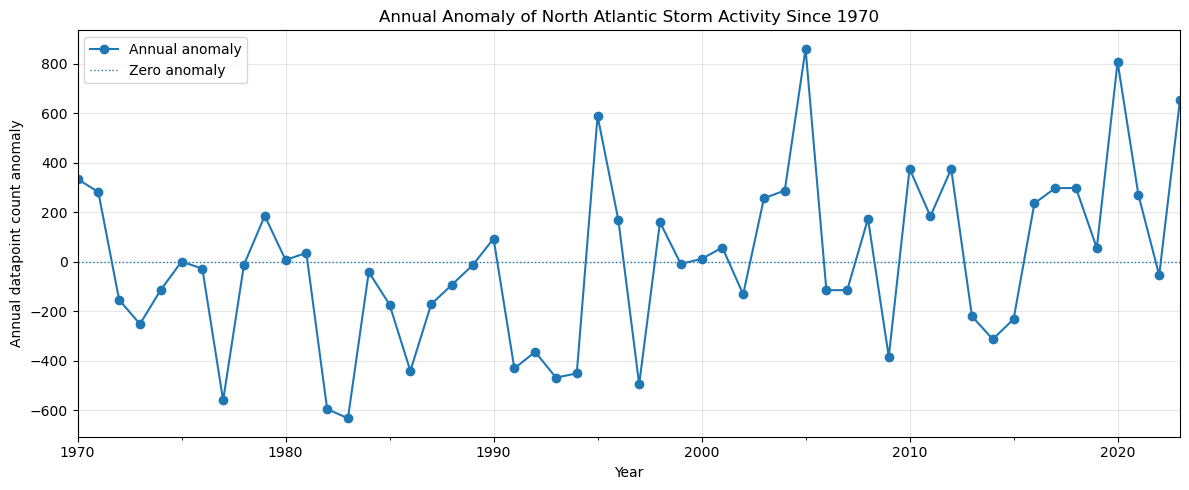

In [14]:
# Resample daily anomalies to annual resolution

annual_count_anomaly = daily_count_anomaly.resample("YE").sum()

fig, ax = plt.subplots(figsize=(12, 5))

annual_count_anomaly.plot(
    ax=ax,
    marker="o",
    label="Annual anomaly"
)

ax.axhline(0, linewidth=1, linestyle=":", label="Zero anomaly")

ax.set_title("Annual Anomaly of North Atlantic Storm Activity Since 1970")
ax.set_xlabel("Year")
ax.set_ylabel("Annual datapoint count anomaly")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [15]:
# Identify years with the largest positive and negative anomalies

annual_anomaly_by_year = annual_count_anomaly.copy()
annual_anomaly_by_year.index = annual_anomaly_by_year.index.year
annual_anomaly_by_year.index.name = "Year"

print("Years with largest positive anomalies:")
display(annual_anomaly_by_year.nlargest(5))

print("Years with largest negative anomalies:")
display(annual_anomaly_by_year.nsmallest(5))

Years with largest positive anomalies:


Year
2005    859.571978
2020    806.571978
2023    653.402166
1995    588.571978
2010    375.571978
dtype: float64

Years with largest negative anomalies:


Year
1983   -631.428022
1982   -594.428022
1977   -559.428022
1997   -494.428022
1993   -467.428022
dtype: float64

The annual anomaly analysis shows that 2005 and 2020 stand out as the most unusually active years for North Atlantic storm activity in this dataset. Other high-anomaly years include 2023, 1995, and 2010. The lowest anomaly years are 1983, 1982, 1977, 1997, and 1993, which had much lower storm activity than expected based on the seasonal climatology.

## 7. Conclusion

This notebook analyzed North Atlantic storm activity since 1970 using the NOAA IBTrACS hurricane track dataset. The annual storm count figure shows strong year-to-year variability, with some very active years such as 2005 and 2020. The daily datapoint count and seasonal climatology figures show that North Atlantic storm activity is strongly seasonal, with activity rising during summer and peaking around late summer and early fall.

The anomaly analysis identifies years when storm activity was unusually high or low relative to the typical seasonal cycle. The strongest positive anomaly years are 2005, 2020, 2023, 1995, and 2010. The strongest negative anomaly years are 1983, 1982, 1977, 1997, and 1993. Overall, the analysis shows that North Atlantic storm activity has large interannual variability and that a small number of years stand out as especially active.

## Limitations

This analysis uses storm datapoints and unique storm IDs from the IBTrACS dataset, so the results reflect both storm occurrence and the number of observations recorded along storm tracks. Changes in observing systems over time may affect how many datapoints are available, especially when comparing earlier and later decades. A fuller project could combine this activity analysis with intensity metrics such as maximum wind speed and minimum pressure.